# Setup

In [3]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

from pathlib import Path
from scipy import signal

DATA_FILES = [
    "/Users/tonyliu/Documents/EMGTuner-master/data/01/1_raw_data_13-12_22.03.16.txt",
    "/Users/tonyliu/Documents/EMGTuner-master/data/01/2_raw_data_13-13_22.03.16.txt",
]

# Loads a EMG text file into a pandas DataFrame. The text file is expected to have a header row and be tab-delimited.
def load_emg_text(path: str) -> pd.DataFrame:
    df = pd.read_csv(path, sep = r"\s+|\t+", engine = "python")

    # Standardize column names
    df.columns = [str(col).strip().lower() for col in df.columns]

    # Ensure data types
    for col in df.columns:
        df[col] = pd.to_numeric(df[col], errors = "coerce")

    # Drop rows with missing critical values
    df = df.dropna(subset = ["time", "class"])

    # Add metadata column for source file
    df["source_file"] = os.path.basename(path)

    return df

dfs = [load_emg_text(file) for file in DATA_FILES]
df1 = dfs[0]
df2 = dfs[1]

# Calculate sampling rate

In [4]:
# Calculate sampling frequency for a dataset
def calculate_fs(df: pd.DataFrame) -> float:
    time_diffs = df["time"].diff()
    median_diff = time_diffs.median()
    fs = float(1000.0 / median_diff)
    return fs

fs1 = calculate_fs(df1)
fs2 = calculate_fs(df2)
print(f"Sampling frequency for dataset 1: {fs1:.2f} Hz")
print(f"Sampling frequency for dataset 2: {fs2:.2f} Hz")

Sampling frequency for dataset 1: 1000.00 Hz
Sampling frequency for dataset 2: 1000.00 Hz


# Visualization (Raw EMG Waveforms for All Channels)

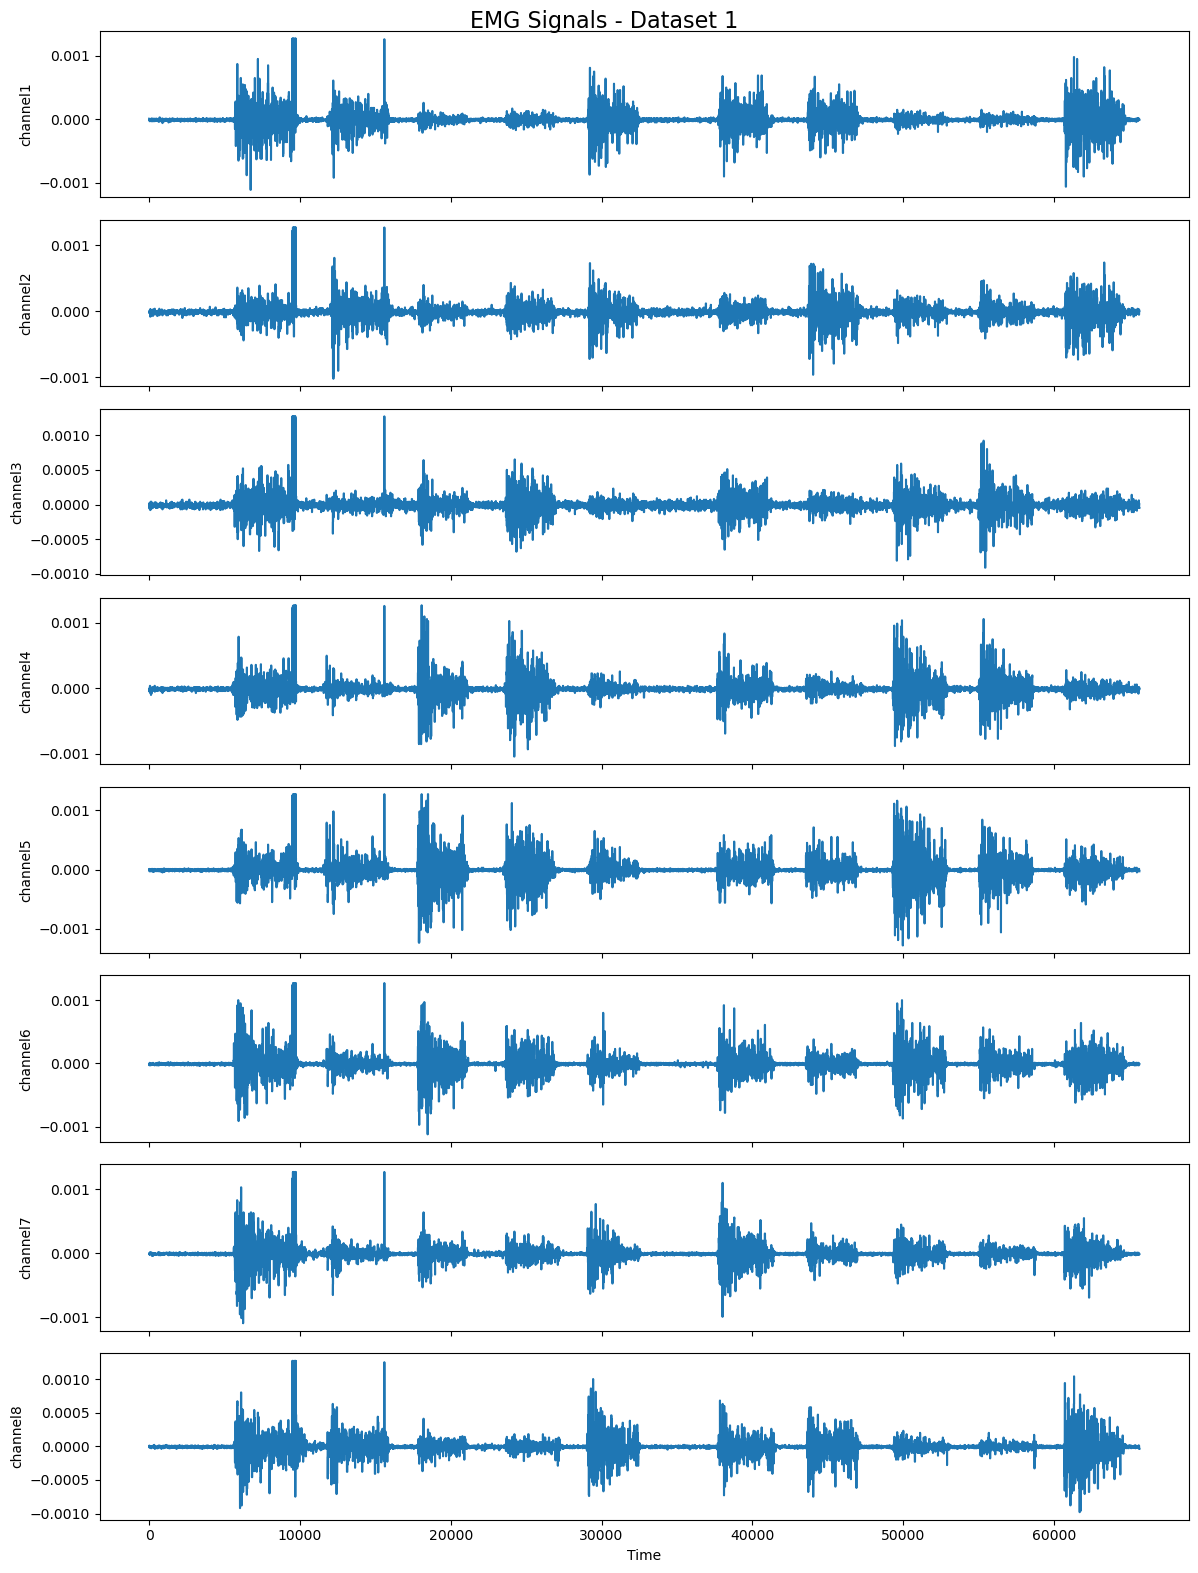

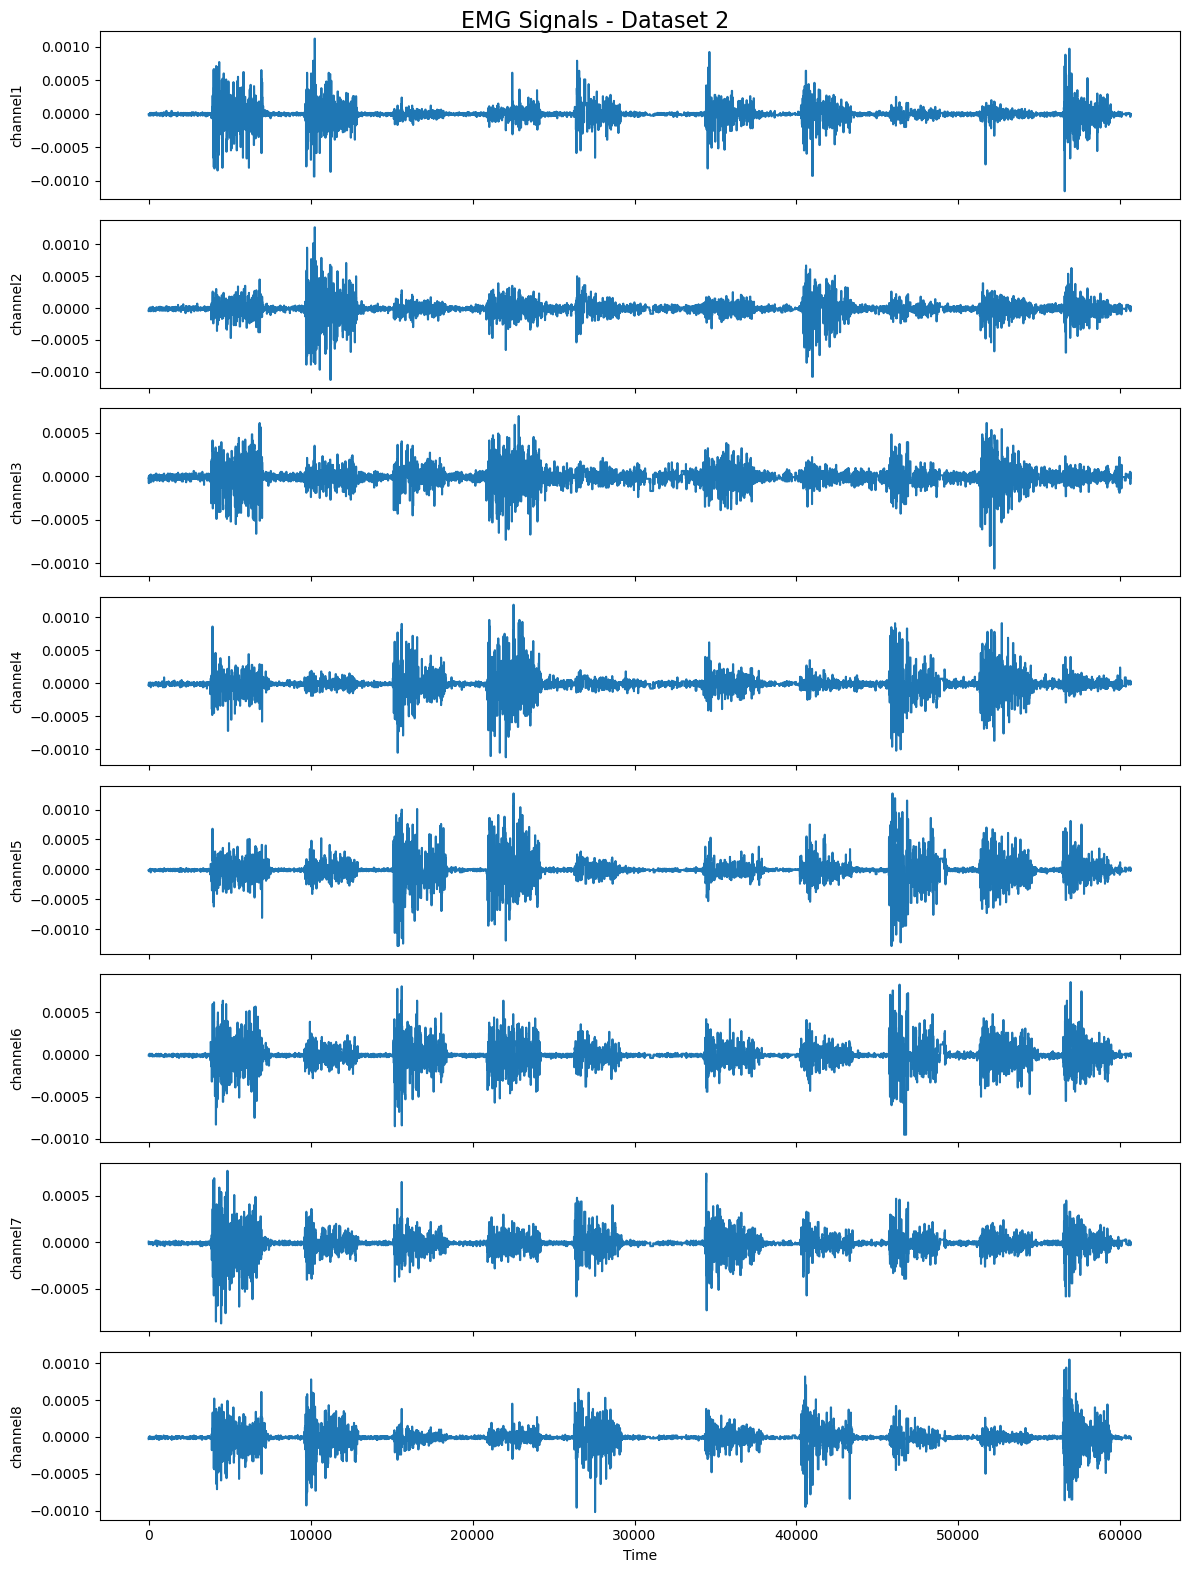

In [5]:
channels = [f"channel{i}" for i in range(1, 9)]

# Plot EMG signals for a given dataset
def plot_emg_signals(df: pd.DataFrame, title: str):
    n = len(df)
    time = df["time"].to_numpy()

    fig, axes = plt.subplots(len(channels), 1, sharex = True, figsize = (12, 2 * len(channels)))
    fig.suptitle(title, fontsize = 16)

    for i, channel in enumerate(channels):
        axes[i].plot(time, df[channel].to_numpy())
        axes[i].set_ylabel(channel)
    
    axes[-1].set_xlabel("Time")
    plt.tight_layout()
    plt.show()

plot_emg_signals(df1, "EMG Signals - Dataset 1")
plot_emg_signals(df2, "EMG Signals - Dataset 2")

# Visualization (Class Labels Over Time)

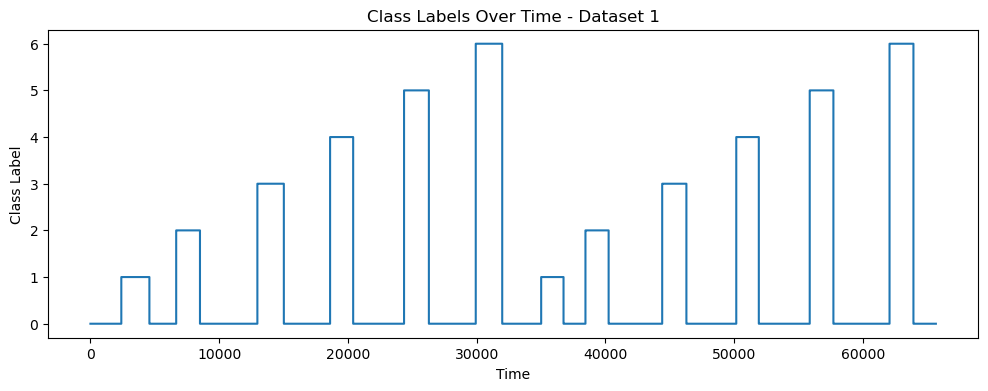

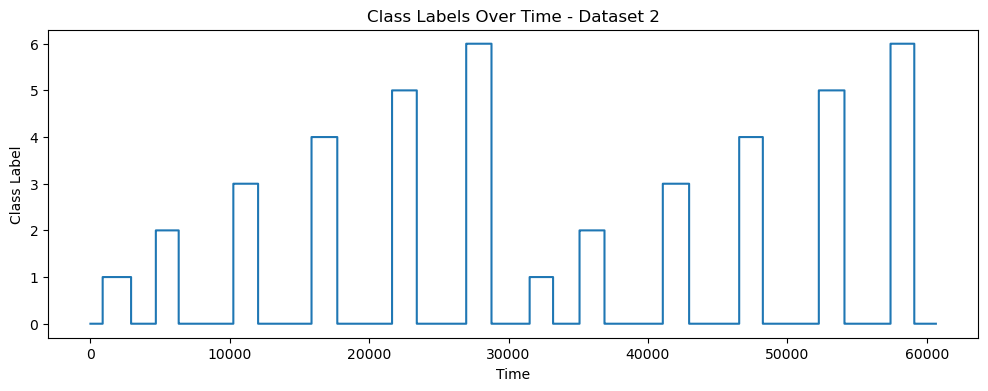

In [6]:
# Plot class labels over time for a given dataset
def plot_class_label_over_time(df: pd.DataFrame, title: str):
    time = df["time"].to_numpy()
    class_labels = df["class"].to_numpy()

    plt.figure(figsize = (12, 4))
    plt.plot(time, class_labels, drawstyle = "steps-post")
    plt.title(title)
    plt.xlabel("Time")
    plt.ylabel("Class Label")
    plt.yticks(np.unique(class_labels))
    plt.show()

plot_class_label_over_time(df1, "Class Labels Over Time - Dataset 1")
plot_class_label_over_time(df2, "Class Labels Over Time - Dataset 2")

# Visualization (RMS)

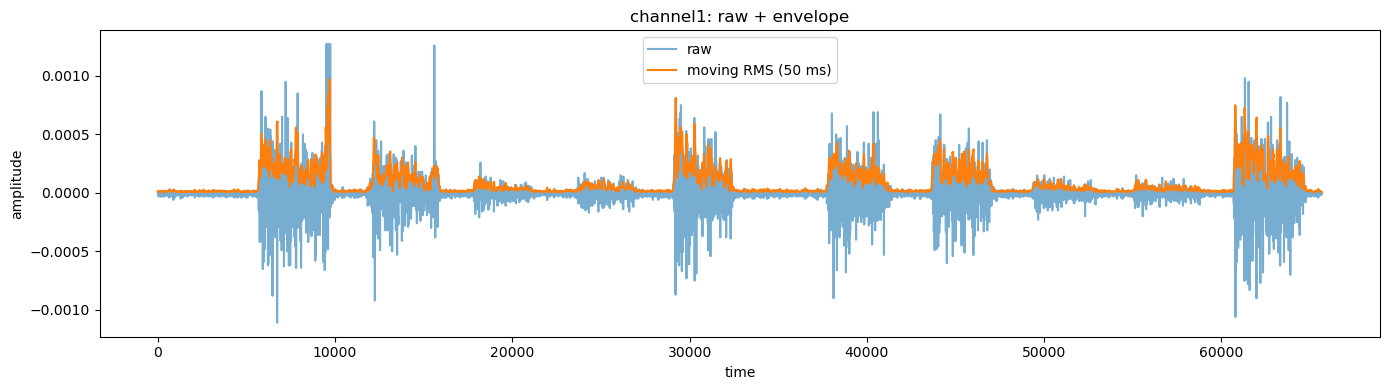

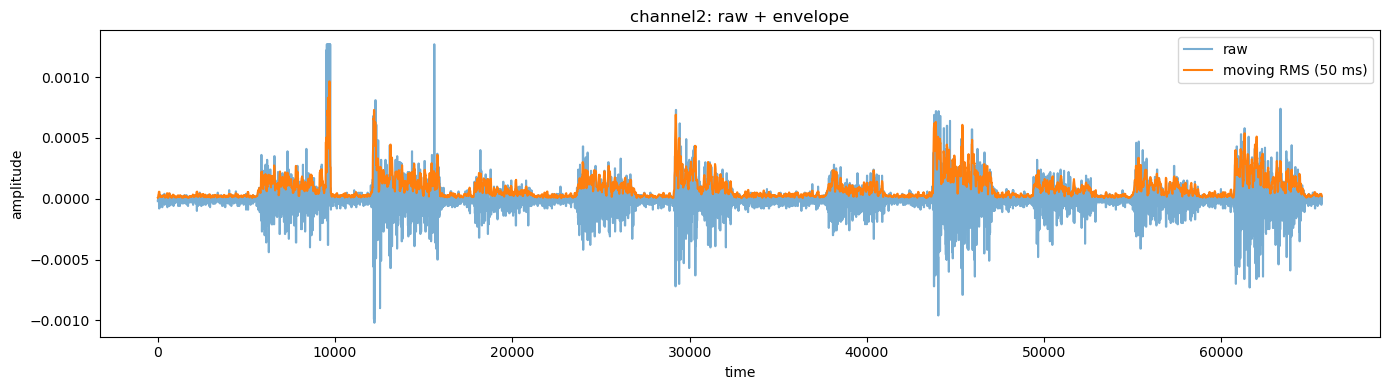

In [7]:
# Calculate RMS over a moving window for a given EMG signal
def moving_rms(x: np.ndarray, window_size: int) -> np.ndarray:
    squared = x ** 2
    kernel = np.ones(window_size) / window_size
    rms = np.sqrt(np.convolve(squared, kernel, mode = "same"))
    return rms

def plot_rms(df: pd.DataFrame, ch: str, fs = None, win_ms = 50):
    n = len(df)        
    t = df["time"].to_numpy()
    x = df[ch].to_numpy()

    # If fs unknown, estimate from df
    if fs is None:
        fs = calculate_fs(df)
    win_samples = max(1, int(fs * (win_ms / 1000.0)))

    rms = moving_rms(x, win_samples)

    plt.figure(figsize = (14, 4))
    plt.plot(t, x, alpha = 0.6, label = "raw")
    plt.plot(t, rms, label = f"moving RMS ({win_ms} ms)")
    plt.title(f"{ch}: raw + envelope")
    plt.xlabel("time")
    plt.ylabel("amplitude")
    plt.legend()
    plt.tight_layout()
    plt.show()

plot_rms(df1, ch="channel1", fs = fs1, win_ms = 50)
plot_rms(df1, ch="channel2", fs = fs1, win_ms = 50)

# Preprocessing (Filtering: Bandpass Filter + Notch Filter)

### Bandpass filter will only keep typical EMG energy (20 Hz - 450 Hz). This removes high frequency noise and removes motion artifacts.
### Notch filter will remove the powerline hum of 60 Hz

In [8]:
channels = [c for c in df1.columns if c.startswith]